In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("BestOfStreamingVideo.csv")

# Display first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.357887e+09,127,69.197.18.162,16d8mp,Django!,enginears,139,12,12,http://www.reddit.com/r/BestOfStreamingVideo/c...,NaN,dead link,False,NaN,t5_2trwh,False,broken,NaN,False,t3_16d8mp,http://69.197.18.162/?629,NaN
1,1.359253e+09,88,self.BestOfStreamingVideo,17cj2u,"Hey mods, could you make it that every time a ...",spyfer,95,7,6,http://www.reddit.com/r/BestOfStreamingVideo/c...,NaN,NaN,False,NaN,t5_2trwh,False,NaN,NaN,True,t3_17cj2u,http://www.reddit.com/r/BestOfStreamingVideo/c...,NaN
2,1.365462e+09,71,putlocker.com,1by7hv,Moon (2009),vre77,78,7,5,http://www.reddit.com/r/BestOfStreamingVideo/c...,NaN,NaN,False,NaN,t5_2trwh,False,NaN,NaN,False,t3_1by7hv,http://www.putlocker.com/file/F5308ZTYMS08CSO#,NaN
3,1.363099e+09,72,throneroom.eu,1a5d9z,Every episode of Game of Thrones season 1 &amp; 2,throneroomeu,82,10,26,http://www.reddit.com/r/BestOfStreamingVideo/c...,NaN,NaN,False,NaN,t5_2trwh,False,NaN,NaN,False,t3_1a5d9z,http://www.throneroom.eu/game-of-thrones-streams/,NaN
4,1.358211e+09,60,1channel.ch,16l4t2,Django Unchained (2012) - [165m],ShreddyMarz,75,15,2,http://www.reddit.com/r/BestOfStreamingVideo/c...,NaN,NaN,False,NaN,t5_2trwh,False,NaN,NaN,False,t3_16l4t2,http://www.1channel.ch/watch-2736970-Django-Un...,NaN


In [3]:
# Dataset information
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             518 non-null    float64
 1   score                   518 non-null    int64  
 2   domain                  518 non-null    str    
 3   id                      518 non-null    str    
 4   title                   518 non-null    str    
 5   author                  515 non-null    str    
 6   ups                     518 non-null    int64  
 7   downs                   518 non-null    int64  
 8   num_comments            518 non-null    int64  
 9   permalink               518 non-null    str    
 10  selftext                7 non-null      str    
 11  link_flair_text         23 non-null     str    
 12  over_18                 518 non-null    bool   
 13  thumbnail               0 non-null      float64
 14  subreddit_id            518 non-null    str    
 15  

created_utc                 0
score                       0
domain                      0
id                          0
title                       0
author                      3
ups                         0
downs                       0
num_comments                0
permalink                   0
selftext                  511
link_flair_text           495
over_18                     0
thumbnail                 518
subreddit_id                0
edited                      0
link_flair_css_class      495
author_flair_css_class    518
is_self                     0
name                        0
url                         0
distinguished             517
dtype: int64

In [5]:
df = df.fillna(0)


In [7]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
df.head()

,created_utc,score,domain,id,title,ups,downs,num_comments,over_18,thumbnail,edited,author_flair_css_class,is_self,author_1plus1equalsfun,author_AbbyMoriah,author_Adizzlefoshizzle,author_Basher_52,author_BentSlightly,author_BigBoss722,author_Bosbo9,author_BrickShitting,author_BrotherChe,author_CheeseRaven,author_DolceSpezia,author_DonMegaTron,author_DopGanger,author_EdgHG,author_Fjordo,author_Foreveralone42875,author_Freshenstein,author_HeckYeahSummer,author_Hey_shrugsshoulders,author_JEWPACOLYPSE,author_JediMasterSam,author_Jkurz,author_JohnnyNoCares,author_Kanuck88,author_KposK17,author_LesjaunesTV,author_ModstRob,...,url_http://youtu.be/jCsHEpQBRJU,url_http://youtu.be/jxP7FNX2nqk,url_http://youtu.be/mf9jJx0NSjw,url_http://youtu.be/ogfUVy82fCY,url_http://youtu.be/pwRI39BID4E,url_http://youtu.be/wsOcVRq-aVQ,url_http://zooupload.com/z5g6toeos3nd,url_https://vimeo.com/40503001,url_https://www.crackle.com/c/Ghostbusters,url_https://www.crackle.com/c/The_Tick,url_https://www.crackle.com/c/seinfeld,url_https://www.youtube.com/watch?v=-Kh3RLS1-vQ&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=0_0kjyKt5l8&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=3msPmLpLTUM&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=5Yo8bvg0MAg,url_https://www.youtube.com/watch?v=6jO_ncXj7RE&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=G7u7mCsI5qk&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=GPuHdibqmTE&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=IP5w2V-5tjw&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=OIOQZCmp02o,url_https://www.youtube.com/watch?v=PQ0PhMH3sLg,url_https://www.youtube.com/watch?v=R6Z4eE2whkI,url_https://www.youtube.com/watch?v=TK_XsZsc3ms,url_https://www.youtube.com/watch?v=Veag-ptUkXI,url_https://www.youtube.com/watch?v=VwE5-ecnH8g,url_https://www.youtube.com/watch?v=XN8ShhpC49s,url_https://www.youtube.com/watch?v=_P80idGxWuo&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=bCkI01_Kvf4&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=bNe-8OZE8W4&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=dUKx7eWuZcs&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=ecQAZoYhpJ8&amp;feature=related,url_https://www.youtube.com/watch?v=f2h9U60rBY0&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=h9BTq1FHw2k,url_https://www.youtube.com/watch?v=kOHs29kR7mU,url_https://www.youtube.com/watch?v=nZBZULpVc5I&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=oJ8lm1mZ-QI&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=qwNbuMCAsSE&amp;feature=youtube_gdata_player,url_https://www.youtube.com/watch?v=qyIZK7GWSPI,url_https://www.youtube.com/watch?v=u0FF2ArAAGo&amp;feature=youtube_gdata_player,distinguished_moderator
0,1.357887e+09,127,2,137,126,139,12,12,False,0.0,False,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.359253e+09,88,50,158,175,95,7,6,False,0.0,False,0.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,1.365462e+09,71,47,305,255,78,7,5,False,0.0,False,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [13]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


In [18]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


In [21]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



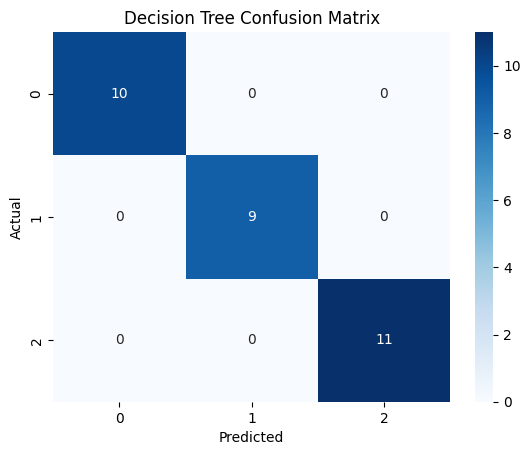

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



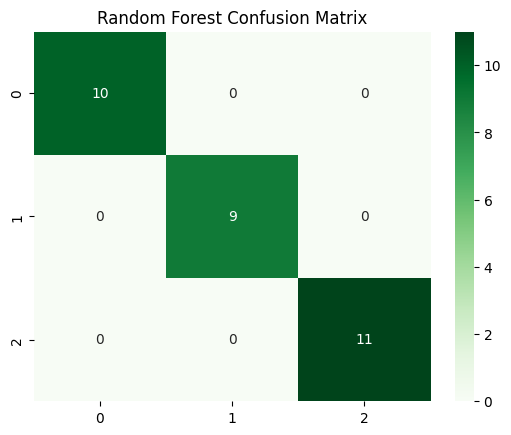

In [26]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [31]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [38]:
# Import libraries
import pandas as pd

df = pd.read_csv("BestOfStreamingVideo.csv")
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')
